<a href="https://colab.research.google.com/github/GARVNAIN19/dsa-ml-journey/blob/main/ml/day04_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

y = df['Survived']
X = df.drop('Survived', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("Ready! ✅")

Ready! ✅


In [2]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(cm)
print("\nWhat this means:")
print(f"True Negatives  (predicted died, actually died):     {cm[0][0]}")
print(f"False Positives (predicted survived, actually died): {cm[0][1]}")
print(f"False Negatives (predicted died, actually survived): {cm[1][0]}")
print(f"True Positives  (predicted survived, actually survived): {cm[1][1]}")

Confusion Matrix:
[[91 14]
 [18 56]]

What this means:
True Negatives  (predicted died, actually died):     91
False Positives (predicted survived, actually died): 14
False Negatives (predicted died, actually survived): 18
True Positives  (predicted survived, actually survived): 56


In [3]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



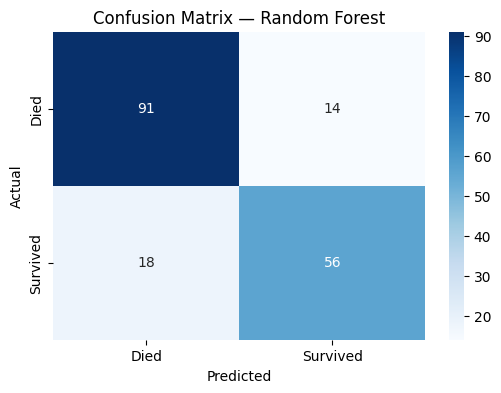

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()